In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix, lil_matrix
from pyproj import Transformer
from sklearn.preprocessing import StandardScaler
import pyreadr 
from pathlib import Path
import os

os.chdir(Path.cwd().parent)


[INFO] S = 1601, T = 2704
[INFO] BYM support on comp1: S = 1068


BYM Y-level PPC: 100%|██████████| 2704/2704 [01:46<00:00, 25.45it/s]


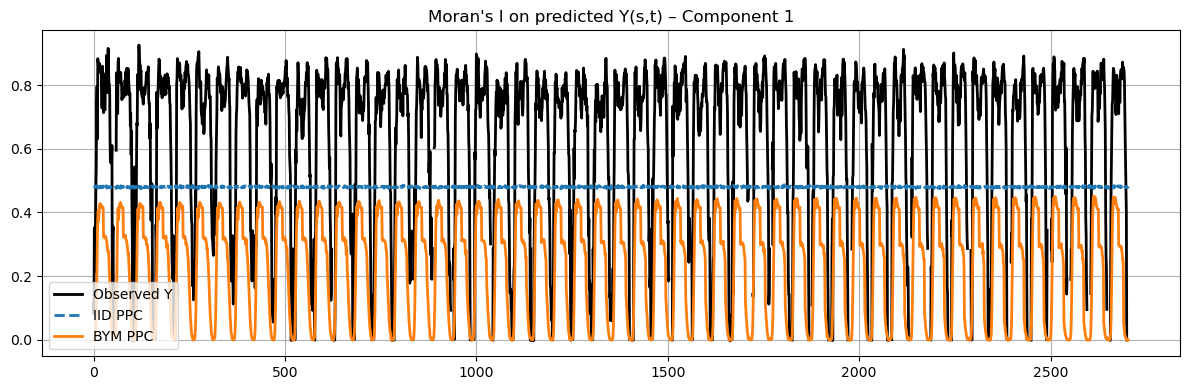

In [12]:
# ================================================================
# Moran's I on predicted Y(s,t)
# IID vs NEW BYM (Y-level PPC)
# ================================================================

import numpy as np
import geopandas as gpd
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from pathlib import Path
import pyreadr
import pickle
import matplotlib.pyplot as plt
from tqdm import tqdm

# ================================================================
# 0. CONFIG
# ================================================================

BASE_DIR = Path(r"D:\77\Research\temp\snow")
PERIOD = 52
DIST_TH = 0.22
N_REP = 200

no_nbs = np.array([
    57,170,236,269,343,685,946,947,989,
    1037,1084,1090,1109,1118,1127,1176,1203
]) - 1

# ================================================================
# 1. LOAD DATA & DROP no_nbs
# ================================================================

snow = pyreadr.read_r(BASE_DIR / "snow_cleaned_full.Rda")
snow = list(snow.values())[0].reset_index(drop=True)

keep_idx = np.setdiff1d(np.arange(snow.shape[0]), no_nbs)

coords = snow.iloc[keep_idx, :2].to_numpy()
y_obs  = snow.iloc[keep_idx, 2:].to_numpy()   # (S, T)

S, T = y_obs.shape
print(f"[INFO] S = {S}, T = {T}")

# ================================================================
# 2. BUILD ADJACENCY W
# ================================================================

gdf = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(coords[:, 0], coords[:, 1]),
    crs="EPSG:4326"
)
gdf = gdf.to_crs("+proj=aeqd +lat_0=90 +lon_0=-100")
xy = np.vstack([gdf.geometry.x, gdf.geometry.y]).T / 1e6

Dmat = squareform(pdist(xy))
W = (Dmat <= DIST_TH).astype(float)
np.fill_diagonal(W, 0)
W = csr_matrix(W)

# ================================================================
# 3. CONNECTED COMPONENTS
# ================================================================

n_comp, labels = connected_components(W, directed=False)
sizes = np.bincount(labels)
order = np.argsort(sizes)[::-1]

comp1_label = order[0]
comp1_idx = np.where(labels == comp1_label)[0]

def subgraph_W(W, idx):
    return W[idx][:, idx]

# ================================================================
# 4. MORAN'S I
# ================================================================

def morans_I_y(x, W):
    x = x.astype(float)
    x = x - x.mean()
    den = np.dot(x, x)
    if den == 0:
        return np.nan
    return (len(x) / W.sum()) * (x @ (W @ x)) / den

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# ================================================================
# 5. OBSERVED MORAN'S I
# ================================================================

W_c1 = subgraph_W(W, comp1_idx)

I_obs = np.array([
    morans_I_y(y_obs[comp1_idx, t], W_c1)
    for t in range(T)
])

# ================================================================
# 6. LOAD MODELS
# ================================================================

# ----- IID -----
iid_theta = np.load(BASE_DIR / "ind01.npz")["all_theta"][keep_idx, :]
iid_theta = iid_theta[comp1_idx, :]   # restrict to comp1

# ----- NEW BYM -----
with open(BASE_DIR / "mcmc_merged_two_largest_components_p01.pkl", "rb") as f:
    bym = pickle.load(f)["p01"]

theta_bym = bym["theta"]      # (K, Wbin, S_merged, M)
keep_bym  = bym["keep_idx"]   # indices in keep_idx-space

# restrict to comp1 & BYM support
comp1_bym_idx = np.intersect1d(comp1_idx, keep_bym)

theta_bym = theta_bym[:, :, comp1_bym_idx, :]

K, Wbin, S_c1, M = theta_bym.shape
print(f"[INFO] BYM support on comp1: S = {S_c1}")

# ================================================================
# 7. COVARIATES (for BYM)
# ================================================================

t_raw = np.arange(T)
t_trend = (t_raw - t_raw.mean()) / t_raw.std()

cov = np.zeros((T, K))
cov[:, 0] = 1
cov[:, 1] = 1
cov[:, 2] = np.cos(2 * np.pi * t_raw / PERIOD)
cov[:, 3] = cov[:, 2]
cov[:, 4] = np.sin(2 * np.pi * t_raw / PERIOD)
cov[:, 5] = cov[:, 4]
cov[:, 6] = t_trend
cov[:, 7] = t_trend

# ================================================================
# 8. PPC: generate Y(s,t) then Moran's I
# ================================================================

def ppc_Y_iid(theta, W, n_rep=200):
    I_mean = np.zeros(T)

    for t in tqdm(range(T), desc="IID Y-level PPC"):
        draws = np.random.choice(theta.shape[1], n_rep, replace=False)
        vals = []
        for m in draws:
            p = sigmoid(theta[:, m])
            y_rep = np.random.binomial(1, p)
            vals.append(morans_I_y(y_rep, W))
        I_mean[t] = np.nanmean(vals)

    return I_mean


def ppc_Y_bym(theta, cov, W, n_rep=200):
    weeks_per_bin, time_bin = 13, 4
    I_mean = np.zeros(T)

    for t in tqdm(range(T), desc="BYM Y-level PPC"):
        w = (t // weeks_per_bin) % time_bin
        draws = np.random.choice(theta.shape[-1], n_rep, replace=False)
        vals = []

        for m in draws:
            eta = np.zeros(theta.shape[2])
            for k in range(K):
                eta += cov[t, k] * theta[k, w, :, m]
            p = sigmoid(eta)
            y_rep = np.random.binomial(1, p)
            vals.append(morans_I_y(y_rep, W))

        I_mean[t] = np.nanmean(vals)

    return I_mean

# ================================================================
# 9. RUN PPC
# ================================================================

I_iid = ppc_Y_iid(iid_theta, W_c1)
I_bym = ppc_Y_bym(theta_bym, cov, W_c1)

# ================================================================
# 10. PLOT
# ================================================================

plt.figure(figsize=(12, 4))
plt.plot(I_obs, color="black", lw=2, label="Observed Y")
plt.plot(I_iid, ls="--", lw=2, label="IID PPC")
plt.plot(I_bym, lw=2, label="BYM PPC")
plt.title("Moran's I on predicted Y(s,t) – Component 1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


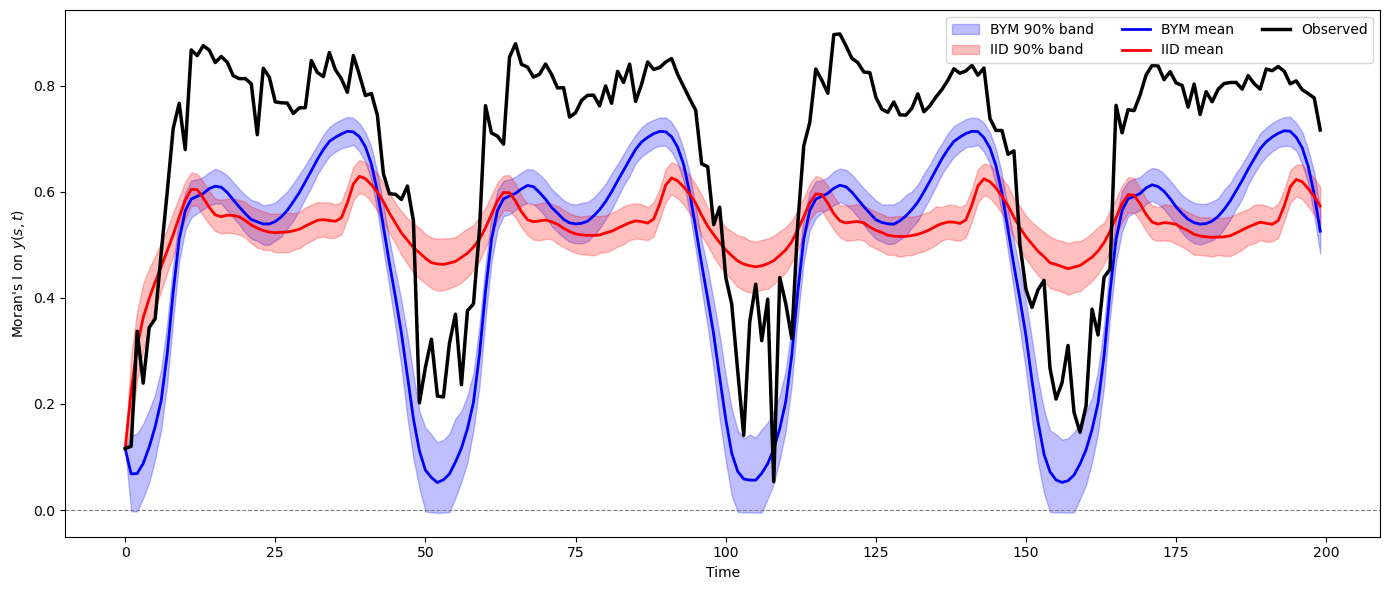

In [33]:
T_show = 200
t_plot = np.arange(T_show)

plt.figure(figsize=(14,6))

# uncertainty bands
plt.fill_between(
    t_plot,
    I_bym_lo[:T_show],
    I_bym_hi[:T_show],
    color="blue", alpha=0.25, label="BYM 90% band"
)
plt.fill_between(
    t_plot,
    I_iid_lo[:T_show],
    I_iid_hi[:T_show],
    color="red", alpha=0.25, label="IID 90% band"
)

# posterior means
plt.plot(t_plot, I_bym_mean[:T_show],
         color="blue", linewidth=2, label="BYM mean")
plt.plot(t_plot, I_iid_mean[:T_show],
         color="red", linewidth=2, label="IID mean")

# observed
plt.plot(t_plot, I_obs[:T_show],
         color="black", linewidth=2.5, label="Observed")

plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("Time")
plt.ylabel("Moran's I on $y(s,t)$")
plt.legend(ncol=3)
plt.tight_layout()
plt.show()
